Rendering Page 1 at 300 DPI...


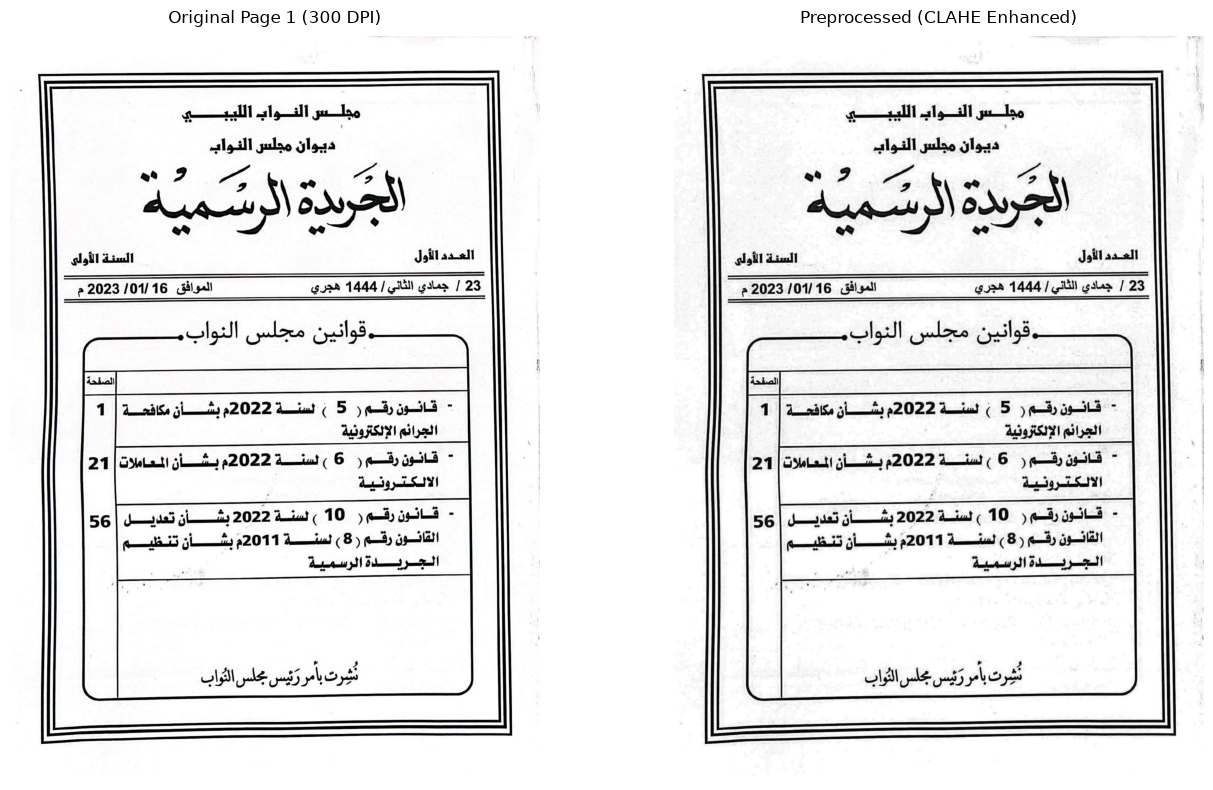

Using CPU. Note: This module is much faster with a GPU.



Loading EasyOCR engine...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


Running OCR on Page 1...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



PAGE 1 OCR EXTRACTION RESULTS
[1] مجلىس النسواب الليب ي ديوان مجلس النواب الجردة الرسمية العدد الأول السنة الأولى 23 جمادي الثاني / 1444 هجري الموافق  01/16/ 2023
[2] . قوانين مجلس النواب
[3] الصفحة
[4] قانسون رقسم ) 5 لسنة 2022م بشسأن مكافعسة الجرائم الإلكترونية قانون رقسم ) 6 لسنسة 2022 م بشسأن العاملات 21 الالكترونية قسانون  دقم ) 10 لسنة 2022 بشأن تعديل 56 القانسون دقسم )8  لسنة 2011م بشأن تنظيم الجري دة الدسمية
[5]  -' .
[6] نشرت بأمررئيس مجلس النواب


In [1]:
import easyocr
import cv2
import numpy as np
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 0: Setup Paths
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Only Page 1
# ---------------------------------------------------------
print("Rendering Page 1 at 300 DPI...")
single_page = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)[0]

# ---------------------------------------------------------
# Step 2: Preprocess Image
# ---------------------------------------------------------
def preprocess_arabic_image(pil_img):
    img = np.array(pil_img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # CLAHE contrast adjustment
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return enhanced

cleaned_img = preprocess_arabic_image(single_page)

# ---------------------------------------------------------
# Step 3: Visual Inspection (Side-by-Side Plot)
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

# Raw PIL Page
plt.subplot(1, 2, 1)
plt.imshow(single_page)
plt.title("Original Page 1 (300 DPI)", fontsize=12)
plt.axis("off")

# Preprocessed Image
plt.subplot(1, 2, 2)
plt.imshow(cleaned_img, cmap="gray")
plt.title("Preprocessed (CLAHE Enhanced)", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Step 4: Run OCR on Page 1
# ---------------------------------------------------------
print("\nLoading EasyOCR engine...")
reader = easyocr.Reader(['ar', 'en'], gpu=False)

print("Running OCR on Page 1...")
# detail=1 returns bounding boxes, text, and confidence scores
results = reader.readtext(cleaned_img, paragraph=True, detail=1)

print("\n" + "="*50)
print("PAGE 1 OCR EXTRACTION RESULTS")
print("="*50)

for idx, (bbox, text) in enumerate(results):
    print(f"[{idx + 1}] {text}")

print("="*50)

In [2]:
import easyocr
import cv2
import numpy as np
import re
from pdf2image import convert_from_path

# ---------------------------------------------------------
# Step 0: Path Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1...")
raw_page = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)[0]

# Convert PIL Image to OpenCV Grayscale
img_np = np.array(raw_page)
gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

# ---------------------------------------------------------
# Step 2: Advanced Preprocessing for Arabic Typeset
# ---------------------------------------------------------
def preprocess_arabic_advanced(gray_img):
    # Fast Non-Local Means Denoising to soften vocalization marks (Tashkeel)
    denoised = cv2.fastNlMeansDenoising(gray_img, h=10, templateWindowSize=7, searchWindowSize=21)
    
    # Mild contrast adjustment without sharp edge blowing
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    
    return enhanced

cleaned_img = preprocess_arabic_advanced(gray)

# ---------------------------------------------------------
# Step 3: Run EasyOCR with Fine-Tuned Detection Parameters
# ---------------------------------------------------------
print("Initializing EasyOCR Engine...")
reader = easyocr.Reader(['ar', 'en'], gpu=False)

print("Running Optimized OCR Detection...")
# mag_ratio=1.5 enlarges text region for better character dot separation
results = reader.readtext(
    cleaned_img, 
    paragraph=True, 
    mag_ratio=1.5,
    text_threshold=0.6,
    low_text=0.3
)

# ---------------------------------------------------------
# Step 4: Rule-Based Post-Processing Cleanup
# ---------------------------------------------------------
def clean_arabic_ocr_text(text):
    """
    Cleans known EasyOCR artifacts caused by stretched connectors and diacritics.
    """
    # 1. Remove extra 'س' artifact in common patterns (e.g., بشسأن -> بشأن, لسنسة -> سنة)
    text = re.sub(r'بشسأن', 'بشأن', text)
    text = re.sub(r'لسنسة', 'لسنة', text)
    text = re.sub(r'شسأن', 'شأن', text)
    text = re.sub(r'قانسون', 'قانون', text)
    
    # 2. Fix common letter misclassifications
    text = re.sub(r'\bدقم\b', 'رقم', text)
    text = re.sub(r'\bقسانون\b', 'قانون', text)
    text = re.sub(r'\bديوان مجلس\b', 'ديوان مجلس', text)
    
    # 3. Remove isolated diacritic/single punctuation noise
    text = re.sub(r'\s+[\-\'\.\`\_]\s+', ' ', text)
    
    # 4. Normalize multiple spaces
    text = re.sub(r' +', ' ', text)
    
    return text.strip()

# ---------------------------------------------------------
# Step 5: Output Comparison
# ---------------------------------------------------------
print("\n" + "="*60)
print("CLEANED & ENHANCED ARABIC OCR OUTPUT")
print("="*60)

for idx, (bbox, text) in enumerate(results):
    cleaned_line = clean_arabic_ocr_text(text)
    print(f"[{idx + 1}] {cleaned_line}")

print("="*60)

Rendering Page 1...


Using CPU. Note: This module is much faster with a GPU.


Initializing EasyOCR Engine...
Running Optimized OCR Detection...

CLEANED & ENHANCED ARABIC OCR OUTPUT
[1] مجلسس النسواب الليب ي ديوان مجلس النواب الجردة الرسمية العدد الأول السنة الأولى 23 / جمادي الثاني / 1444 هجري الموافق 01/16/ 2023 قوانين مجلس النواب ,
[2] الصفحة قانون رقم ) 5 ( لسنة 2022م بشيأن مكافحسة 1 الجرائم الإلكترونية قانون = رقسم ) 6 لسنة 2022م بشأن العاملات 27 الالكترونية قانون رقم ) 10 ( لسنة 2022 بشأن تعديسل 56 القانون رقسم )8( لسنة 2011م بشأنتنظيم الجري دة الرسمية
[3] نشرت بأمررئيس مجلس النواب


In [6]:
import cv2
import numpy as np
from pdf2image import convert_from_path
from paddleocr import PaddleOCR

# ---------------------------------------------------------
# Step 0: Paths Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1 using Poppler at 300 DPI...")
pages = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)

img_np = np.array(pages[0])
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# ---------------------------------------------------------
# Step 2: Initialize PaddleOCR Engine
# Explicitly pass enable_mkldnn=False to bypass PIR conversion bug
# ---------------------------------------------------------
print("Initializing PaddleOCR engine with Arabic language support...")
ocr = PaddleOCR(
    lang='ar',
    use_textline_orientation=True,
    device='cpu',
    enable_mkldnn=False  # <-- FIX: Prevents the oneDNN/PIR crash
)

# ---------------------------------------------------------
# Step 3: Run Text Recognition
# ---------------------------------------------------------
print("Running PaddleOCR extraction on Page 1...")
results = ocr.predict(img_bgr)

# ---------------------------------------------------------
# Step 4: Display Results
# ---------------------------------------------------------
print("\n" + "="*60)
print("PADDLEOCR EXTRACTION RESULTS (PAGE 1)")
print("="*60)

for res in results:
    if hasattr(res, 'str'):
        print(res.str())
    elif isinstance(res, dict) and 'rec_text' in res:
        for text, score in zip(res['rec_text'], res['rec_score']):
            print(f"{text} (Confidence: {score:.2f})")
    else:
        print(res)

print("="*60)

Rendering Page 1 using Poppler at 300 DPI...


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)


Initializing PaddleOCR engine with Arabic language support...


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('arabic_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\arabic_PP-OCRv5_mobile_rec`.


Running PaddleOCR extraction on Page 1...


: 

In [1]:
import cv2
import numpy as np
from pdf2image import convert_from_path
from paddleocr import PaddleOCR

# ---------------------------------------------------------
# Step 0: Path Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1 using Poppler at 300 DPI...")
pages = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)

img_np = np.array(pages[0])
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# ---------------------------------------------------------
# Step 2: Initialize PaddleOCR
# ---------------------------------------------------------
print("Initializing PaddleOCR engine with Arabic language support...")
ocr = PaddleOCR(
    lang='ar',
    use_textline_orientation=True,
    device='cpu'
)

# ---------------------------------------------------------
# Step 3: Run Text Extraction
# ---------------------------------------------------------
print("Running PaddleOCR extraction on Page 1...")
results = list(ocr.predict(img_bgr))

# ---------------------------------------------------------
# Step 4: Display Results
# ---------------------------------------------------------
print("\n" + "="*60)
print("PADDLEOCR EXTRACTION RESULTS (PAGE 1)")
print("="*60)

for idx, item in enumerate(results):
    # Format and display output text safely
    if hasattr(item, 'str'):
        print(f"[{idx + 1}] {item.str()}")
    elif isinstance(item, dict) and 'rec_text' in item:
        texts = item['rec_text']
        scores = item.get('rec_score', [0.0] * len(texts))
        for t, s in zip(texts, scores):
            print(f"- {t} (Confidence: {s:.2f})")
    else:
        print(f"[{idx + 1}] {item}")

print("="*60)

Rendering Page 1 using Poppler at 300 DPI...


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Initializing PaddleOCR engine with Arabic language support...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: (

Running PaddleOCR extraction on Page 1...

PADDLEOCR EXTRACTION RESULTS (PAGE 1)


TypeError: 'dict' object is not callable

In [2]:
import cv2
import numpy as np
from pdf2image import convert_from_path
from paddleocr import PaddleOCR

# ---------------------------------------------------------
# Step 0: Path Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1 using Poppler at 300 DPI...")
pages = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)

img_np = np.array(pages[0])
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# ---------------------------------------------------------
# Step 2: Initialize PaddleOCR Engine
# ---------------------------------------------------------
print("Initializing PaddleOCR engine with Arabic language support...")
ocr = PaddleOCR(
    lang='ar',
    use_textline_orientation=True,
    device='cpu'
)

# ---------------------------------------------------------
# Step 3: Run Text Extraction
# ---------------------------------------------------------
print("Running PaddleOCR extraction on Page 1...")
results = list(ocr.predict(img_bgr))

# ---------------------------------------------------------
# Step 4: Display Results (PaddleOCR v3.x Data Format)
# ---------------------------------------------------------
print("\n" + "="*60)
print("PADDLEOCR EXTRACTION RESULTS (PAGE 1)")
print("="*60)

for idx, res in enumerate(results):
    # Standard PaddleX result handling
    if hasattr(res, 'print'):
        res.print()  # Built-in visual printer for PaddleX results
    elif isinstance(res, dict):
        # Extract fields directly from dictionary
        texts = res.get('rec_text') or res.get('rec_texts') or []
        scores = res.get('rec_score') or res.get('rec_scores') or [0.0] * len(texts)
        
        for line_num, (text, score) in enumerate(zip(texts, scores), 1):
            print(f"[{line_num}] {text} (Confidence: {score:.2f})")
    else:
        print(f"[{idx + 1}] {res}")

print("="*60)

Rendering Page 1 using Poppler at 300 DPI...
Initializing PaddleOCR engine with Arabic language support...


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('arabic_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the dir

Running PaddleOCR extraction on Page 1...


{'res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': True}, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0}, 'dt_polys': array([[[ 818,  126],
        ...,
        [ 819,  197]],

       ...,

       [[ 704, 2192],
        ...,
        [ 704, 2289]]], shape=(46, 4, 2), dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([1, ..., 0], shape=(46,)), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['ا لاب', '', 'ااي', 'ااي', 'يلة يي', 'اي', 'IEE', 'اية', 'اع ال', '9L /L0/ £Z0Z', 'ا يي', 'ل  ي', 'اية', '£Z 1', 'ايلي', 'ي', 'ي', 'االلية', 'لسنة م بشأن مكافحة', '1', 'رقم', 'قانون', 'الإلكترونية', 'الجرائم', '21', 'لسنةم بشأن 


PADDLEOCR EXTRACTION RESULTS (PAGE 1)


In [1]:
import cv2
import numpy as np
from pdf2image import convert_from_path
from paddleocr import PaddleOCR

# ---------------------------------------------------------
# Step 0: Path Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1 at 300 DPI...")
pages = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)

img_np = np.array(pages[0])
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# ---------------------------------------------------------
# Step 2: Initialize PaddleOCR Engine
# ---------------------------------------------------------
print("Initializing PaddleOCR Engine...")
ocr = PaddleOCR(lang='ar', device='cpu')

# ---------------------------------------------------------
# Step 3: Run Prediction (Disable buggy unwarping models here)
# ---------------------------------------------------------
print("Running PaddleOCR Extraction...")
results = ocr.predict(
    img_bgr,
    use_doc_orientation_classify=False,  # Bypass PP-LCNet_x1_0_doc_ori
    use_doc_unwarping=False,             # Bypass UVDoc (Source of the RuntimeError)
    use_textline_orientation=True
)

# ---------------------------------------------------------
# Step 4: Display Clean Output
# ---------------------------------------------------------
print("\n" + "="*60)
print("PADDLEOCR EXTRACTION RESULTS (PAGE 1)")
print("="*60)

for page_res in results:
    # Handle dict structures returned by PaddleOCR v3.x
    res_data = page_res.get('res', page_res) if isinstance(page_res, dict) else page_res
    
    if isinstance(res_data, dict):
        texts = res_data.get('rec_texts') or res_data.get('rec_text') or []
        scores = res_data.get('rec_scores') or res_data.get('rec_score') or [0.0] * len(texts)
        
        for idx, (text, score) in enumerate(zip(texts, scores), 1):
            if text.strip():
                print(f"[{idx:02d}] {text} (Confidence: {score:.2f})")

print("="*60)

Rendering Page 1 at 300 DPI...


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Initializing PaddleOCR Engine...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\PC-LAB1\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: (

Running PaddleOCR Extraction...

PADDLEOCR EXTRACTION RESULTS (PAGE 1)
[01] ااب (Confidence: 0.39)
[03] اي (Confidence: 0.63)
[04] اوإب (Confidence: 0.44)
[05] ي ة يي (Confidence: 0.43)
[06] ا يي (Confidence: 0.54)
[07] العدد الأول (Confidence: 0.96)
[08] السنة الأولى (Confidence: 0.96)
[09] جمادي الثاني هجري (Confidence: 0.79)
[10] الموافق (Confidence: 0.99)
[11] النواب (Confidence: 0.92)
[12] مجلس (Confidence: 0.82)
[13] ي يس (Confidence: 0.46)
[14] اة (Confidence: 0.54)
[16] رةإِ (Confidence: 0.38)
[17] L (Confidence: 0.99)
[18] ايي (Confidence: 0.52)
[19] ليوييل (Confidence: 0.52)
[22] اِ (Confidence: 0.38)
[23] LZ (Confidence: 0.99)
[24] يية (Confidence: 0.38)
[25] لسنةبشأن (Confidence: 0.73)
[26] رقم (Confidence: 0.85)
[27] قانون (Confidence: 0.99)
[28] 56 (Confidence: 1.00)
[29] تعديل (Confidence: 0.86)
[30] ٥ بأن (Confidence: 0.69)
[31] ة (Confidence: 0.53)
[32] 8 (Confidence: 0.81)
[34] ايي (Confidence: 0.49)
[36] الي (Confidence: 0.52)
[37] الجريدة (Confidence: 0.89)
[38] ثشر

In [2]:
import cv2
import numpy as np
import easyocr
from pdf2image import convert_from_path

# ---------------------------------------------------------
# Step 0: Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"

# ---------------------------------------------------------
# Step 1: Render Page 1
# ---------------------------------------------------------
print("Rendering Page 1 at 300 DPI...")
pages = convert_from_path(
    pdf_path, dpi=300, first_page=1, last_page=1, poppler_path=POPPLER_BIN_PATH
)
img_np = np.array(pages[0])

# ---------------------------------------------------------
# Step 2: Image Preprocessing (Noise Reduction for EasyOCR)
# ---------------------------------------------------------
print("Applying image preprocessing...")
# Convert to grayscale
gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

# Increase contrast to make text pop and background white out
alpha = 1.5 # Contrast control
beta = -50  # Brightness control
enhanced = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

# Apply a median blur to remove small speckles/noise that EasyOCR misinterprets as letters
clean_img = cv2.medianBlur(enhanced, 3)

# ---------------------------------------------------------
# Step 3: Run EasyOCR
# ---------------------------------------------------------
print("Initializing EasyOCR Engine...")
reader = easyocr.Reader(['ar'], gpu=False)

print("Running Extraction...")
# We use detail=1 to get bounding boxes and confidence scores
results = reader.readtext(clean_img, detail=1)

# ---------------------------------------------------------
# Step 4: Filter and Display
# ---------------------------------------------------------
print("\n" + "="*60)
print("EASYOCR ENHANCED EXTRACTION RESULTS (PAGE 1)")
print("="*60)

# Sort results top-to-bottom
results.sort(key=lambda x: x[0][0][1])

CONFIDENCE_THRESHOLD = 0.40  # Filter out low-confidence noise

for idx, (bbox, text, score) in enumerate(results, 1):
    if score >= CONFIDENCE_THRESHOLD and text.strip():
        print(f"[{idx:02d}] {text} (Confidence: {score:.2f})")

print("="*60)

Rendering Page 1 at 300 DPI...


Using CPU. Note: This module is much faster with a GPU.


Applying image preprocessing...
Initializing EasyOCR Engine...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


Running Extraction...


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



EASYOCR ENHANCED EXTRACTION RESULTS (PAGE 1)
[01] مجلسس النسواب الليبي (Confidence: 0.85)
[02] ديوان مجلس النواب (Confidence: 0.84)
[03] الرسمية (Confidence: 0.68)
[05] العدد الأول (Confidence: 0.96)
[06] السنة الأولى (Confidence: 0.54)
[07] جمادي الثاتى / 1444 هجري (Confidence: 0.50)
[08] / 23 (Confidence: 0.70)
[09] الموافق (Confidence: 0.87)
[10] 2023 /01/16 (Confidence: 0.86)
[11] مجلس النواب (Confidence: 0.89)
[12] قوانين (Confidence: 0.96)
[13] م (Confidence: 1.00)
[14] الصلحة (Confidence: 0.80)
[15] لسنة 2022م بشأن مكافعسة (Confidence: 0.70)
[17] الجرانم الإلكترونية (Confidence: 0.78)
[19] لسنسة 2022 م بشان العاملات (Confidence: 0.63)
[20] 6 (Confidence: 1.00)
[21] 21 (Confidence: 1.00)
[22] الالكترونية (Confidence: 1.00)
[23] قسانون رقىم ) 10 (Confidence: 0.40)
[24] لسنة 2022 بشأن تعديسل (Confidence: 0.67)
[25] 56 (Confidence: 1.00)
[27] الجسريدة الرسمية (Confidence: 0.58)
[28] نشرت بأمررئيس . (Confidence: 0.54)
[29]  النواب (Confidence: 0.78)
[30] مجلس (Confidence: 1.00)


In [3]:
import cv2
import numpy as np
import easyocr
from pdf2image import convert_from_path

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
POPPLER_BIN_PATH = r"C:\Poppler\Release-26.09.0-0\poppler-26.09.0\Library\bin"
pdf_path = r"C:\Users\PC-LAB1\img_processing_lab\day10\العدد-الأول-من-الجريدة-الرسمية.pdf"
output_file = "easyocr_extracted_arabic.txt"
CONFIDENCE_THRESHOLD = 0.40

# ---------------------------------------------------------
# Initialize EasyOCR Engine
# ---------------------------------------------------------
print("Initializing EasyOCR Engine...")
reader = easyocr.Reader(['ar'], gpu=False)

# ---------------------------------------------------------
# Convert PDF to Images
# ---------------------------------------------------------
print("Converting PDF to images...")
pages = convert_from_path(pdf_path, dpi=300, poppler_path=POPPLER_BIN_PATH)
print(f"Total Pages to Process: {len(pages)}")

# ---------------------------------------------------------
# Batch Processing
# ---------------------------------------------------------
extracted_pages = []

for page_idx, page in enumerate(pages, 1):
    print(f"Processing Page {page_idx}/{len(pages)}...")
    img_np = np.array(page)
    
    # Preprocessing pipeline
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    enhanced = cv2.convertScaleAbs(gray, alpha=1.5, beta=-50)
    clean_img = cv2.medianBlur(enhanced, 3)
    
    # Extraction
    results = reader.readtext(clean_img, detail=1)
    
    # Sort top-to-bottom based on the Y-coordinate of the top-left bounding box corner
    results.sort(key=lambda x: x[0][0][1])
    
    page_lines = []
    for bbox, text, score in results:
        if score >= CONFIDENCE_THRESHOLD and text.strip():
            page_lines.append(text.strip())
            
    # Format page output
    page_content = f"--- PAGE {page_idx} ---\n" + "\n".join(page_lines)
    extracted_pages.append(page_content)

# ---------------------------------------------------------
# Save to File
# ---------------------------------------------------------
full_document_text = "\n\n".join(extracted_pages)
with open(output_file, "w", encoding="utf-8") as f:
    f.write(full_document_text)

print(f"\nDocument extraction complete! Saved to: {output_file}")

Using CPU. Note: This module is much faster with a GPU.


Initializing EasyOCR Engine...
Converting PDF to images...
Total Pages to Process: 58
Processing Page 1/58...
Processing Page 2/58...
Processing Page 3/58...
Processing Page 4/58...
Processing Page 5/58...
Processing Page 6/58...
Processing Page 7/58...
Processing Page 8/58...
Processing Page 9/58...
Processing Page 10/58...
Processing Page 11/58...
Processing Page 12/58...
Processing Page 13/58...
Processing Page 14/58...
Processing Page 15/58...
Processing Page 16/58...
Processing Page 17/58...
Processing Page 18/58...
Processing Page 19/58...
Processing Page 20/58...
Processing Page 21/58...
Processing Page 22/58...
Processing Page 23/58...
Processing Page 24/58...
Processing Page 25/58...
Processing Page 26/58...
Processing Page 27/58...
Processing Page 28/58...
Processing Page 29/58...
Processing Page 30/58...
Processing Page 31/58...
Processing Page 32/58...
Processing Page 33/58...
Processing Page 34/58...
Processing Page 35/58...
Processing Page 36/58...
Processing Page 37/58..